# Step 4 — Fast Approximate Sampling: Matrix-product States

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 4 of 4 (Read-only)**

This notebook is **based on notebook 03**: the same 9-zone problem and the same XY circuit —
run on the *approximate* `tensornet-mps` backend, tuned for speed.

**Matrix-product states (MPS)** store the quantum state as a chain of small tensors, one per
qubit, whose neighbor-connections have width **χ** (the *bond dimension*).

**The headline benefit is memory — and you can calculate it exactly, no measurement needed:**

- a state vector of 36 qubits stores $2^{36}$ amplitudes: $2^{36} \times 8$ bytes ≈ **550 GB**;
- the χ=16 MPS needs about $n \cdot 2\chi^2 \cdot 8 = 36 \cdot 2 \cdot 16^2 \cdot 8$ bytes ≈
  **0.15 MB** — roughly a factor of **3.7 million** less memory (and about 16× less than the
  χ=64 default's ≈ 2.4 MB).

The speed gain over the exact tensor network is modest and varies run to run; the memory saving
is enormous and exact — it is why MPS scales to sizes nothing else touches. The price: whenever
the true state needs more width than χ, the simulator **truncates**. What truncation does to
*this* workload was measured in a sweep at a fixed set of angles (2,000 sampling shots per
setting; `CUDAQ_MPS_ABS_CUTOFF` tested at its default `1e-5` and a looser `1e-4`; exact
reference energy at those angles from the exact tensor network):

| bond χ | cutoff | energy readout | s / evaluation | valid colorings in 2,000 shots |
|---|---|---|---|---|
| 2 | 1e-5 | 158.0 | 6.5 | 0 |
| 8 | 1e-5 | 92.1 | 10.3 | 4 (0.20%) |
| 16 | 1e-5 | 9.6 | 11.0 | 20 (1.00%) |
| 32 | 1e-5 | 1.9 | 12.5 | 19 (0.95%) |
| 64 | 1e-5 | 2.3 | 16.4 | 24 (1.20%) |
| 2 | 1e-4 | 158.0 | 5.9 | 0 |
| 8 | 1e-4 | 126.5 | 9.8 | 18 (0.90%) |
| **16** | **1e-4 — used below** | **8.0** | **9.9** | **12 (0.60%)** |
| 32 | 1e-4 | 3.6 | 11.7 | 26 (1.30%) |
| 64 | 1e-4 | 3.7 | 12.4 | 19 (0.95%) |

Two clear patterns. **Solution quality** (valid colorings from sampling — what a solver actually
delivers) collapses at χ=2, starts recovering by χ=8, and **plateaus from χ=16 on** at about
the same ~1% rate the exact simulator gives. **Cost** keeps climbing with χ. So **χ=16 with the
looser `1e-4` cutoff is the chosen trade-off — picked for the extra speed** (9.9 vs 11.0 s per
evaluation in the sweep) at a still-robust solution quality: 12 valid colorings in its
2,000-shot sweep sample (0.60%).

One honest disclosure, up front: the χ=16 **energy readout is not to be trusted** — at that
fixed set of angles the sweep read ~8.0 where the exact
value is 3.5021 — far off. That is an intentional trade-off: we judge this solver by the
*colorings it samples* (each one checked exactly, bit by bit), not by its energy meter.

In [1]:
# Cell 1 — chosen MPS settings FIRST, then the same problem.
import os
os.environ["CUDAQ_MPS_MAX_BOND"] = "16"      # the speed-quality sweet spot (default is 64)
os.environ["CUDAQ_MPS_ABS_CUTOFF"] = "1e-4"  # loosened from the 1e-5 default — for extra-speed pick

import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq            # <- the settings above are picked up here

cudaq.set_random_seed(1234)
cudaq.set_target("tensornet-mps", option="fp32")   # approximate tensor-network simulator
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")

taiwan = hp.load_map()
NODES = hp.ZONE_ORDER                # the 9 zones, as in notebooks 02-03
EDGES = taiwan["zone_edges"]
K = 4
A, B = 8.0, 1.0
N = len(NODES) * K                   # 36 qubits

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)
print(f"same problem as notebooks 02-03: {N} qubits, "
      f"{len(terms['z'])} Z + {len(terms['zz'])} ZZ terms, offset {offset}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3
same problem as notebooks 02-03: 36 qubits, 36 Z + 110 ZZ terms, offset 158.0


## 1 · The same XY circuit

Similar setting as usual — W-state start (exactly one color per zone by construction),
cost layer, XY ring mixer, only one- and two-qubit gates. Same mathematics, third simulator.

In [2]:
# Cell 2 — the XY circuit (identical to notebooks 02-03).
W_ANGLES = [2.0943951023931953, 1.9106332362490186, 1.5707963267948966]

@cudaq.kernel
def xy_kernel(n: int, zq: list[int], zc: list[float], zz1: list[int],
              zz2: list[int], zzc: list[float], wa: list[float],
              ra: list[int], rb: list[int], gammas: list[float], betas: list[float]):
    q = cudaq.qvector(n)
    for v in range(n // 4):                           # W-state start on each zone
        base = 4 * v
        x(q[base])
        for k in range(3):
            ry.ctrl(wa[k], q[base + k], q[base + k + 1])
            x.ctrl(q[base + k + 1], q[base + k])
    for layer in range(len(gammas)):
        for i in range(len(zq)):                      # cost layer
            rz(2.0 * gammas[layer] * zc[i], q[zq[i]])
        for i in range(len(zz1)):
            x.ctrl(q[zz1[i]], q[zz2[i]])
            rz(2.0 * gammas[layer] * zzc[i], q[zz2[i]])
            x.ctrl(q[zz1[i]], q[zz2[i]])
        for i in range(len(ra)):                      # XY mixer
            a = ra[i]
            b = rb[i]
            h(q[a])
            h(q[b])
            x.ctrl(q[a], q[b])
            rz(2.0 * betas[layer], q[b])
            x.ctrl(q[a], q[b])
            h(q[a])
            h(q[b])
            rx(1.5707963267948966, q[a])
            rx(1.5707963267948966, q[b])
            x.ctrl(q[a], q[b])
            rz(2.0 * betas[layer], q[b])
            x.ctrl(q[a], q[b])
            rx(-1.5707963267948966, q[a])
            rx(-1.5707963267948966, q[b])

ring_a, ring_b = [], []
for v in range(len(NODES)):
    for a, b in [(0, 1), (1, 2), (2, 3), (3, 0)]:
        ring_a.append(4 * v + a)
        ring_b.append(4 * v + b)

def energy(params):
    return cudaq.observe(xy_kernel, H, N, zq, zc, zz1, zz2, zzc, W_ANGLES,
                         ring_a, ring_b, [params[0]], [params[1]]).expectation() + offset

## 2 · End to end: optimize, then sample

The usual workflow — a five-evaluation Nelder–Mead optimization on the χ=16 simulator, starting
fresh from `[0.1, 0.1]` (no angles carried over from earlier notebooks), then sampling at the
optimized angles. The optimizer steers by the χ=16 energy
meter — imperfect, but the sweep showed the *sampled* solution quality holds up, and that is
what gets checked. Valid counts vary a little from run to run on this backend — that is normal.

In [3]:
# Cell 3 — optimization on the chi=16 simulator.
num_iterations = 5
optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = [0.1, 0.1]
start = time.perf_counter()
best_mps, theta_mps = optimizer.optimize(dimensions=2, function=energy)
t_opt = time.perf_counter() - start
print(f"chi=16 best readout {best_mps:.4f} at gamma = {theta_mps[0]:.4f}, "
      f"beta = {theta_mps[1]:.4f}   ({t_opt:.0f} s for {num_iterations} evaluations)")

chi=16 best readout 12.7084 at gamma = 0.1000, beta = 1.6708   (37 s for 5 evaluations)


In [4]:
# Cell 4 — 2,000 shots at the optimized angles (sampling only AFTER optimizing).
SHOTS = 2000
start = time.perf_counter()
result = cudaq.sample(xy_kernel, N, zq, zc, zz1, zz2, zzc, W_ANGLES,
                      ring_a, ring_b, [theta_mps[0]], [theta_mps[1]], shots_count=SHOTS)
t_sample = time.perf_counter() - start
counts = {}
for bitstring, times_seen in result.items():
    counts[bitstring] = times_seen
print(f"sampled {SHOTS:,} shots in {t_sample:.0f} s")

summary = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE explicit validity step and the notebook's one check: decode the best sampled
# bitstring and verify it is a valid zone coloring.
assert summary["best"] is not None and hp.is_valid(summary["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid zone coloring "
      "(energy 0, verified exactly bit by bit)")

sampled 2,000 shots in 14 s
valid colorings among raw samples: 20 / 2,000 shots = 1.0000%  (20 distinct bitstrings)
best valid coloring: '100000100010010010000100001000010010' (sampled 1 times, energy 0.0)
   Taipei=0, Keelung=2, Taoyuan-Hsinchu-Miaoli=2, Yilan=1, Taichung-Changhua-Nantou=0, Yunlin-Chiayi=1, Tainan=2, South=3, East=2
check passed: the best sampled bitstring is a valid zone coloring (energy 0, verified exactly bit by bit)


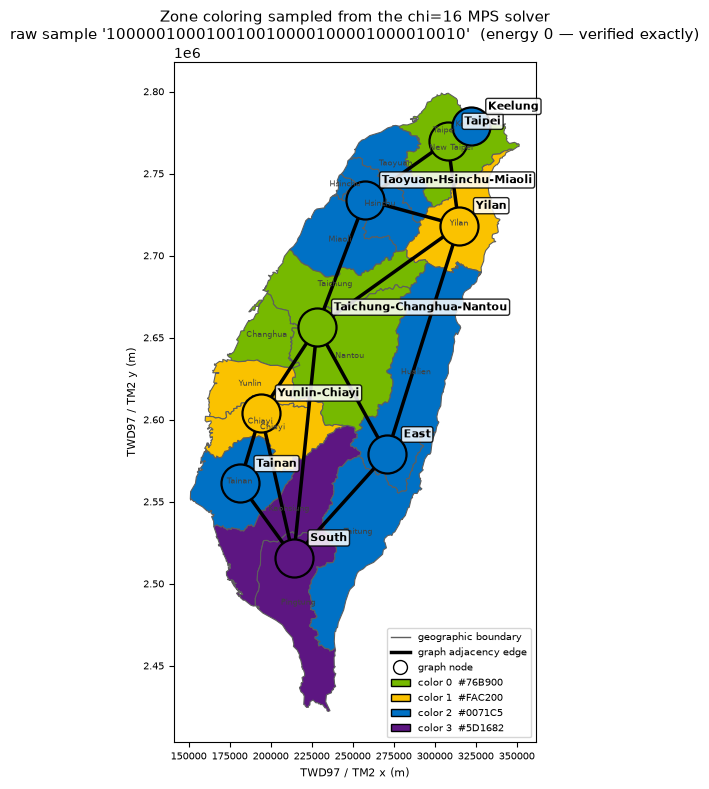

In [5]:
# Cell 5 — visualize on the map for the coloring.
best_coloring = summary["assignment"]
unit_colors = {}
for name, county in taiwan["counties"].items():
    unit_colors[name] = hp.PALETTE[best_coloring[county["zone"]]]
node_colors = {}
for zone in hp.ZONE_ORDER:
    node_colors[zone] = hp.PALETTE[best_coloring[zone]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "zone"),
                      edges=EDGES, node_colors=node_colors,
                      unit_labels=True, color_legend=True,
                      title="Zone coloring sampled from the chi=16 MPS solver\n"
                            f"raw sample '{summary['best']}'  (energy 0 — verified exactly)")
plt.show()

## 3 · What you should take away — and the series in one look

1. **Approximation quality is task-dependent — measure the quality you actually need.** The
   χ=16 energy meter is far off, but the sampled colorings — the thing a solver delivers — match
   the exact simulator's quality at lower cost. The sweep table is what responsible tuning of an
   approximate method looks like. And the memory story needs no measurement at all: **0.15 MB
   versus 550 GB is a calculation** — the real reason MPS scales to sizes nothing else touches.
2. **χ=2 is a warning.** Compress too far and the solution quality itself collapses. There is always a floor; find it by sweeping, not by hoping.

**The series, in one line each:**
- **00** — the full QAOA workflow on 16 qubits, a plain COBYLA baseline, exact CPU vs GPU.
- **01** — first improvements: a better optimizer (much lower energy) and the
  GPU tuning switches, honestly timed against the baseline.
- **02** — the state-vector memory wall; tensor networks; a circuit that encodes the rules beats
  one that doesn't.
- **03** — plan once, reuse the plan: several-times-cheaper evaluations on identical mathematics.
- **04** — an approximate solver for additional speedup with a trade-off in accuracy.